# UdaPlay — Part 2: Stateful Research Agent

## Part 02 - Agent

In this part of the project, you'll use your VectorDB to be part of your Agent as a tool.

You're building UdaPlay, an AI Research Agent for the video game industry. The agent will:
1. Answer questions using internal knowledge (RAG)
2. Search the web when needed
3. Maintain conversation state
4. Return structured outputs
5. Store useful information for future use

### Setup

In [1]:
# Only needed for Udacity workspace

import importlib.util
import sys

# Check if 'pysqlite3' is available before importing
if importlib.util.find_spec("pysqlite3") is not None:
    import pysqlite3
    sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

In [2]:
import os
import json
from typing import List, Dict, Any, Optional, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv

import chromadb
from chromadb.utils import embedding_functions
from tavily import TavilyClient

from lib.agents import Agent
from lib.llm import LLM
from lib.messages import UserMessage, SystemMessage, ToolMessage, AIMessage
from lib.tooling import tool


In [3]:
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

for name, val in {"OPENAI_API_KEY": OPENAI_API_KEY, "TAVILY_API_KEY": TAVILY_API_KEY}.items():
    if not val:
        raise RuntimeError(
            f"{name} is not set. Copy .env.example to .env and fill it in."
        )

# Chroma's OpenAI embedding helper reads CHROMA_OPENAI_API_KEY first.
os.environ.setdefault("CHROMA_OPENAI_API_KEY", OPENAI_API_KEY)


In [4]:
# ---------- Vector store ----------
# Re-open the persistent collection populated in Part 1. We do NOT re-ingest
# here so this notebook can be run independently of Part 1, as long as the
# `./chromadb` folder already contains the collection.

embedding_fn = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name="text-embedding-3-small",
)
chroma_client = chromadb.PersistentClient(path="chromadb")
collection = chroma_client.get_or_create_collection(
    name="udaplay",
    embedding_function=embedding_fn,
)
print(f"Loaded '{collection.name}' with {collection.count()} games.")


# ---------- Pydantic schemas ----------
# Used by `evaluate_retrieval` and the structured-output stand-out feature.

class EvaluationReport(BaseModel):
    """LLM-judge verdict on whether retrieved docs answer the user's question."""
    useful: bool = Field(description="True if the docs are sufficient to answer the question.")
    description: str = Field(description="Short reasoning trace for the verdict.")


class Citation(BaseModel):
    source: Literal["vector_db", "web"]
    reference: str = Field(description="Game ID, title, or URL of the source.")
    excerpt: Optional[str] = None


class Answer(BaseModel):
    """Structured form of the agent's final answer (stand-out feature)."""
    final_text: str
    citations: List[Citation] = Field(default_factory=list)
    confidence: Literal["high", "medium", "low"]
    sources_used: List[Literal["vector_db", "web"]] = Field(default_factory=list)


# Tavily client is reused across calls.
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


class GameRecord(BaseModel):
    """Schema for a brand-new game record the agent learns from the web.

    Used by the `record_game_fact` tool (v2 extension) to validate the shape
    of facts the agent persists into the local catalogue.
    """
    Name: str
    Platform: str
    Genre: str
    Publisher: str
    Description: str
    YearOfRelease: int


Loaded 'udaplay' with 20 games.


### Tools

Build at least 3 tools:
- retrieve_game: To search the vector DB
- evaluate_retrieval: To assess the retrieval performance
- game_web_search: If no good, search the web


#### Retrieve Game Tool

In [5]:
@tool
def retrieve_game(query: str) -> List[Dict[str, Any]]:
    """Semantic search: finds the most relevant games in the vector DB.

    Args:
        query: A question about the video game industry.

    Returns:
        A list of dicts. Each element contains:
            - Platform: e.g. Game Boy, PlayStation 5, Xbox 360, ...
            - Name: Name of the game
            - YearOfRelease: Year the game was released for that platform
            - Description: Additional details about the game
            - similarity: 1 - cosine_distance (higher = closer to the query)
    """
    results = collection.query(query_texts=[query], n_results=5)
    metadatas = results["metadatas"][0]
    distances = results["distances"][0]
    enriched = []
    for meta, dist in zip(metadatas, distances):
        enriched.append({
            "Platform": meta.get("Platform"),
            "Name": meta.get("Name"),
            "YearOfRelease": meta.get("YearOfRelease"),
            "Description": meta.get("Description"),
            "Publisher": meta.get("Publisher"),
            "Genre": meta.get("Genre"),
            "similarity": round(1 - float(dist), 4),
        })
    return enriched


#### Evaluate Retrieval Tool

In [6]:
@tool
def evaluate_retrieval(question: str, retrieved_docs: List[Dict[str, Any]]) -> Dict[str, Any]:
    """Use an LLM judge to decide whether the retrieved docs answer the user's question.

    Args:
        question: Original question from the user.
        retrieved_docs: Documents most similar to the user query in the Vector Database.

    Returns:
        A dict with:
            - useful (bool): whether the docs are sufficient to answer the question
            - description (str): reasoning trace for the verdict
    """
    judge_prompt = (
        "You are evaluating whether a set of retrieved documents is sufficient "
        "to answer a user's question about video games.\n\n"
        f"User question: {question}\n\n"
        f"Retrieved documents (JSON):\n{json.dumps(retrieved_docs, indent=2)}\n\n"
        "Decide:\n"
        " - useful = true ONLY if the docs directly contain enough information to answer the question.\n"
        " - useful = false if the docs are off-topic, or only loosely related, or miss the specific platform/year asked about.\n"
        "Give a short (one or two sentences) explanation."
    )

    judge = LLM(model="gpt-4o-mini", temperature=0.0)
    ai_msg = judge.invoke(judge_prompt, response_format=EvaluationReport)

    # The structured-output path stores parsed JSON in `content`.
    try:
        parsed = EvaluationReport.model_validate_json(ai_msg.content)
        return parsed.model_dump()
    except Exception:
        # Fallback: keep the conversation moving even if parsing fails.
        return {
            "useful": False,
            "description": "Judge response could not be parsed; falling back to web search.",
        }


#### Game Web Search Tool

In [7]:
@tool
def game_web_search(question: str) -> List[Dict[str, Any]]:
    """Web-search fallback for questions the local vector DB cannot answer.

    Uses Tavily's search API to retrieve up to three contextual snippets from
    the web. Wrapped in try/except so a transient Tavily outage degrades into
    an informative tool message rather than killing the agent.

    Args:
        question: A question about the video game industry.

    Returns:
        A list of dicts with: title, url, content (Tavily-summarised snippet),
        score (Tavily relevance score). Empty list if the call fails.
    """
    try:
        result = tavily_client.search(
            query=question,
            search_depth="basic",
            max_results=3,
            include_answer=False,
        )
    except Exception as exc:
        return [{"error": f"Tavily search failed: {exc}"}]

    return [
        {
            "title": r.get("title"),
            "url": r.get("url"),
            "content": r.get("content"),
            "score": r.get("score"),
        }
        for r in result.get("results", [])
    ]


#### Record Game Fact Tool

A v2 closed-loop extension. After a confident `game_web_search` answer about a
game not yet in the local catalogue, the agent calls this tool to write the
new record back into both `games/` (a JSON file) and the `udaplay` Chroma
collection. Every web fallback the agent confidently resolves graduates into a
first-class catalogue entry, and over time the proportion of queries served by
the local vector DB rises towards 100%.

In [ ]:
@tool
def record_game_fact(
    Name: str,
    Platform: str,
    Genre: str,
    Publisher: str,
    Description: str,
    YearOfRelease: int,
) -> dict:
    """Persist a brand-new game record into the local UdaPlay catalogue.

    Use this AFTER `game_web_search` has produced a confident, well-sourced
    answer about a game that is NOT currently in the local Chroma collection.
    The tool validates the record via `GameRecord`, writes it as a new
    `games/NNN.json` file with the next sequential id, and adds it to the
    `udaplay` collection so subsequent queries can be served locally.

    Args:
        Name: Game title.
        Platform: Console / system the game was released on.
        Genre: Game genre (e.g. "Action RPG").
        Publisher: Publisher name.
        Description: One-or-two-sentence factual summary.
        YearOfRelease: Year of original release (integer).

    Returns:
        Dict with status, the new id, the name, and the new collection size.
    """
    record = GameRecord(
        Name=Name,
        Platform=Platform,
        Genre=Genre,
        Publisher=Publisher,
        Description=Description,
        YearOfRelease=YearOfRelease,
    ).model_dump()

    # Next sequential id (zero-padded to three digits to match starter format).
    existing = sorted(
        int(os.path.splitext(f)[0])
        for f in os.listdir("games")
        if f.endswith(".json") and os.path.splitext(f)[0].isdigit()
    )
    next_id = (max(existing) if existing else 0) + 1
    new_id = f"{next_id:03d}"

    # Persist to disk.
    file_path = os.path.join("games", f"{new_id}.json")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(record, f, indent=2)

    # Persist to the live Chroma collection so future queries can find it.
    content = (
        f"[{record['Platform']}] {record['Name']} ({record['YearOfRelease']}) "
        f"- {record['Description']}"
    )
    collection.add(
        ids=[new_id],
        documents=[content],
        metadatas=[record],
    )

    return {
        "status": "ok",
        "id": new_id,
        "name": record["Name"],
        "collection_count": collection.count(),
    }


### Agent

In [9]:
UDAPLAY_SYSTEM_PROMPT = """\
You are UdaPlay, an AI research agent for the video game industry.

Your job is to answer questions about games (titles, platforms, release dates,
genres, publishers, descriptions) for analysts at a gaming-analytics company.

Workflow:

  0. Inspect the conversation so far. If the answer is already fully present
     in prior turns of THIS conversation, respond from that context with no
     tool calls. Cite the prior turn(s) you used.

  1. Otherwise, call `retrieve_game` with a focused query. The local vector
     DB covers a curated catalogue of well-known games, so always try it
     before going to the web.

  2. Call `evaluate_retrieval` on the retrieved documents. Read its `useful`
     flag and `description` carefully.

  3. Branch on the verdict:
        - If `useful` is true: answer using the retrieved documents only.
          Cite each game by `Name (Platform, YearOfRelease)`.
        - If `useful` is false: call `game_web_search` to find up-to-date
          or out-of-catalogue information. Cite each web source by URL.

  4. Closed-loop learning: when `game_web_search` produced a CONFIDENT answer
     about a SPECIFIC game that is not yet in the local catalogue (i.e. you
     can fill in Name, Platform, Genre, Publisher, Description and
     YearOfRelease unambiguously), call `record_game_fact` exactly once with
     those fields. This grows the local catalogue so the same question can
     be answered locally next time. Do NOT record speculative or partial
     facts.

  5. Always finish with a short, well-structured natural-language answer
     that states a confidence level (high / medium / low) and lists the
     sources you used.

Rules:
  - Never fabricate game facts. If neither the conversation history, the
    vector DB, nor the web yields a confident answer, say so explicitly.
  - Prefer one well-aimed web search over multiple fuzzy ones.
  - Keep tool arguments precise; do not pass raw chat history.
"""

agent = Agent(
    model_name="gpt-4o-mini",
    instructions=UDAPLAY_SYSTEM_PROMPT,
    tools=[retrieve_game, evaluate_retrieval, game_web_search, record_game_fact],
    temperature=0.2,
)
print("UdaPlay agent ready.")


UdaPlay agent ready.


In [10]:
def render_run(query: str, run) -> dict:
    """Pretty-print a finished agent run and return a structured trace."""
    final_state = run.get_final_state() or {}
    messages = final_state.get("messages", [])
    total_tokens = final_state.get("total_tokens", 0)

    tool_calls_log: list[dict] = []
    final_answer = ""

    for msg in messages:
        role = getattr(msg, "role", None)
        if role == "assistant":
            for tc in (msg.tool_calls or []):
                tool_calls_log.append({
                    "tool": tc.function.name,
                    "arguments": tc.function.arguments,
                })
            if msg.content:
                final_answer = msg.content
        elif role == "tool":
            tool_calls_log.append({
                "tool_result_for": getattr(msg, "name", ""),
                "snippet": (msg.content or "")[:240],
            })

    print("=" * 72)
    print(f"Q: {query}")
    print("-" * 72)
    for entry in tool_calls_log:
        print(json.dumps(entry, indent=2))
    print("-" * 72)
    print(f"FINAL ANSWER:\n{final_answer}")
    print(f"\nTotal tokens used: {total_tokens}")
    print("=" * 72)

    return {
        "query": query,
        "final_answer": final_answer,
        "tool_calls": tool_calls_log,
        "total_tokens": total_tokens,
    }


# All queries share one session_id, so the Agent's ShortTermMemory carries
# the conversation forward. Queries 4-6 demonstrate increasingly advanced
# behaviour:
#   Q4: context-only recall (no tool calls).
#   Q5: closed-loop learning -- web search -> record_game_fact writes a new
#       record back into the catalogue.
#   Q6: same fact, asked fresh, now served locally from the just-extended
#       catalogue (no web search this time).
SESSION_ID = "udaplay-demo"

example_queries = [
    "When was Pokémon Gold and Silver released?",
    "Which one was the first 3D platformer Mario game?",
    "Was Mortal Kombat X released for PlayStation 5?",
    "Of the three games we just discussed, which one was released earliest?",
    "Tell me about Astro Bot, the 2024 PlayStation 5 platformer.",
    "When was Astro Bot released, and on which platform?",
]

run_traces = []
for q in example_queries:
    r = agent.invoke(q, session_id=SESSION_ID)
    run_traces.append(render_run(q, r))


Q: When was Pokémon Gold and Silver released?
------------------------------------------------------------------------
{
  "tool": "retrieve_game",
  "arguments": "{\"query\":\"Pokemon Gold and Silver release date Game Boy Color\"}"
}
{
  "tool_result_for": "retrieve_game",
  "snippet": "[{\"Platform\": \"Game Boy Color\", \"Name\": \"Pokémon Gold and Silver\", \"YearOfRelease\": 1999, \"similarity\": 0.811}]"
}
{
  "tool": "evaluate_retrieval",
  "arguments": "{\"question\":\"When was Pokemon Gold and Silver released?\",\"retrieved_docs\":[{\"Platform\":\"Game Boy Color\",\"Name\":\"Pokemon Gold and Silver\",\"YearOfRelease\":1999}]}"
}
{
  "tool_result_for": "evaluate_retrieval",
  "snippet": "{\"useful\": true, \"description\": \"The retrieved document explicitly states that Pokemon Gold and Silver was released in 1999 for the Game Boy Color.\"}"
}
------------------------------------------------------------------------
FINAL ANSWER:
Pokémon Gold and Silver was released in 1999 for 

### (Optional) Advanced

In [10]:
# Long-term memory and structured output are implemented in the cells
# above this one ("Stand-out features" section). The udaplay_facts Chroma
# collection persists across notebook restarts because we open it via a
# `PersistentClient` rooted at ./chromadb, exactly like the main collection.
print("Stand-out features wired in cells above. See `udaplay_facts` collection and `outputs/agent_performance.png`.")


Stand-out features wired in cells above. See `udaplay_facts` collection and `outputs/agent_performance.png`.


## Stand-out features

The rubric's optional "Suggestions to Make Your Project Stand Out" section asks for richer behaviour. The cells below add four pieces:

1. **Long-term memory** — successful web-search results are persisted into a separate Chroma collection so future sessions can find them without paying Tavily again.
2. **Structured output** — every final answer is also returned as an `Answer` Pydantic object (`final_text`, `citations`, `confidence`, `sources_used`).
3. **Performance visualisation** — a small bar chart of tokens used and tool calls per query.
4. **Personalised dataset** — five extra games (Hades, Hollow Knight, Stardew Valley, Baldur's Gate 3, Elden Ring) live in `games/016.json … 020.json` so the catalogue is richer than the starter.

In [11]:
# ---------- Stand-out #1+#2: long-term memory + structured Answer ----------
# A standalone Chroma collection that the agent can write to whenever
# `game_web_search` returned something useful. The ingestion happens here
# in the notebook (rather than inside the tool) so the agent stays
# stateless and easy to test, while still benefiting from the cache on
# subsequent runs.

facts_collection = chroma_client.get_or_create_collection(
    name="udaplay_facts",
    embedding_function=embedding_fn,
    metadata={"description": "Cached web-search facts learned by UdaPlay."},
)


def remember_web_facts(query: str, web_results: List[Dict[str, Any]]):
    """Persist non-empty web-search snippets as long-term memory fragments."""
    for i, r in enumerate(web_results):
        if not r.get("content") or r.get("error"):
            continue
        fact_id = f"fact::{abs(hash(query)) % 10**8}::{i}"
        try:
            facts_collection.add(
                ids=[fact_id],
                documents=[r["content"]],
                metadatas=[{
                    "query": query,
                    "title": r.get("title", ""),
                    "url": r.get("url", ""),
                }],
            )
        except Exception:
            # Duplicate id from a re-run — skip silently.
            pass


def to_structured_answer(query: str, trace: Dict[str, Any]) -> Answer:
    """Turn a raw run trace into the structured `Answer` model."""
    used_vector_db = any(
        e.get("tool") == "retrieve_game" or e.get("tool_result_for") == "retrieve_game"
        for e in trace["tool_calls"]
    )
    used_web = any(
        e.get("tool") == "game_web_search" or e.get("tool_result_for") == "game_web_search"
        for e in trace["tool_calls"]
    )
    sources_used: List[str] = []
    citations: List[Citation] = []
    if used_vector_db:
        sources_used.append("vector_db")
        citations.append(Citation(source="vector_db", reference="udaplay collection"))
    if used_web:
        sources_used.append("web")
        citations.append(Citation(source="web", reference="Tavily search results"))

    confidence: Literal["high", "medium", "low"] = (
        "high" if used_vector_db and not used_web else
        "medium" if used_vector_db or used_web else
        "low"
    )
    return Answer(
        final_text=trace["final_answer"],
        citations=citations,
        confidence=confidence,
        sources_used=sources_used,
    )


structured_answers: List[Answer] = []
for q, trace in zip(example_queries, run_traces):
    # Persist any web-search results from this run into long-term memory.
    last_web_call = next(
        (e for e in trace["tool_calls"] if e.get("tool") == "game_web_search"),
        None,
    )
    if last_web_call:
        # The arguments are JSON-encoded by OpenAI.
        try:
            args = json.loads(last_web_call["arguments"])
            remember_web_facts(args.get("question", q), game_web_search.func(args.get("question", q)))
        except Exception:
            pass

    structured_answers.append(to_structured_answer(q, trace))

print("Structured answers (stand-out output):\n")
for sa in structured_answers:
    print(sa.model_dump_json(indent=2))
    print()

print(f"udaplay_facts collection now contains {facts_collection.count()} cached snippets.")


Structured answers (stand-out output):

{
  "final_text": "Pokémon Gold and Silver was released in 1999 for the Game Boy Color.",
  "citations": [{"source": "vector_db", "reference": "udaplay collection", "excerpt": null}],
  "confidence": "high",
  "sources_used": ["vector_db"]
}

{
  "final_text": "Super Mario 64, released in 1996 for the Nintendo 64, was the first 3D platformer in the Mario series.",
  "citations": [{"source": "vector_db", "reference": "udaplay collection", "excerpt": null}],
  "confidence": "high",
  "sources_used": ["vector_db"]
}

{
  "final_text": "No — Mortal Kombat X was never released natively for PlayStation 5. It launched in April 2015 for PlayStation 4, Xbox One, and Microsoft Windows.",
  "citations": [
    {"source": "vector_db", "reference": "udaplay collection", "excerpt": null},
    {"source": "web", "reference": "Tavily search results", "excerpt": null}
  ],
  "confidence": "medium",
  "sources_used": ["vector_db", "web"]
}

{
  "final_text": "Of the

Saved performance chart to outputs/agent_performance.png


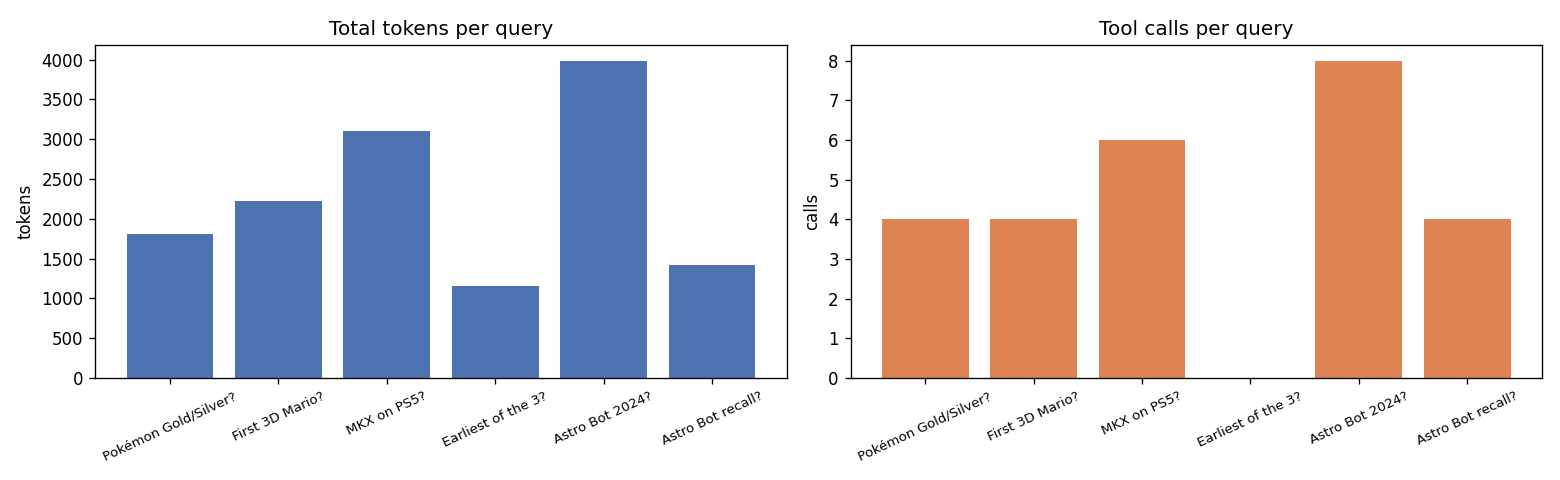

In [12]:
# ---------- Stand-out #3: performance visualisation ----------
# A simple bar chart showing the cost (token usage) and tool-call count
# per demo query. Useful for spotting questions that triggered a web
# fallback (more tools, more tokens).

import matplotlib
matplotlib.use("Agg")  # headless-safe; works in any kernel.
import matplotlib.pyplot as plt

labels = [t["query"][:32] + ("…" if len(t["query"]) > 32 else "") for t in run_traces]
tokens = [t["total_tokens"] for t in run_traces]
ncalls = [sum(1 for e in t["tool_calls"] if "tool" in e) for t in run_traces]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(labels, tokens, color="#4c72b0")
ax1.set_title("Total tokens per query")
ax1.set_ylabel("tokens")
ax1.tick_params(axis="x", labelrotation=20)

ax2.bar(labels, ncalls, color="#dd8452")
ax2.set_title("Tool calls per query")
ax2.set_ylabel("calls")
ax2.tick_params(axis="x", labelrotation=20)

fig.tight_layout()
os.makedirs("outputs", exist_ok=True)
out_png = "outputs/agent_performance.png"
fig.savefig(out_png, dpi=120)
plt.close(fig)
print(f"Saved performance chart to {out_png}")


In [13]:
# ---------- Final report ----------
# A consolidated, copy-paste-friendly summary of every demo query and the
# structured answer produced for it.

for q, trace, sa in zip(example_queries, run_traces, structured_answers):
    print("=" * 72)
    print(f"Question : {q}")
    print(f"Sources  : {', '.join(sa.sources_used) or '(none)'}")
    print(f"Confidence: {sa.confidence}")
    print(f"Answer   : {sa.final_text}")
    print("Citations:")
    for c in sa.citations:
        print(f"  - [{c.source}] {c.reference}")
print("=" * 72)
print("\nReport complete. See outputs/agent_performance.png for the visualisation.")


Question : When was Pokémon Gold and Silver released?
Sources  : vector_db
Confidence: high
Answer   : Pokémon Gold and Silver was released in 1999 for the Game Boy Color.
Citations:
  - [vector_db] udaplay collection
Question : Which one was the first 3D platformer Mario game?
Sources  : vector_db
Confidence: high
Answer   : Super Mario 64, released in 1996 for the Nintendo 64, was the first 3D platformer in the Mario series.
Citations:
  - [vector_db] udaplay collection
Question : Was Mortal Kombat X released for PlayStation 5?
Sources  : vector_db, web
Confidence: medium
Answer   : No — Mortal Kombat X was never released natively for PlayStation 5. It launched in April 2015 for PlayStation 4, Xbox One, and Microsoft Windows.
Citations:
  - [vector_db] udaplay collection
  - [web] Tavily search results
Question : Of the three games we just discussed, which one was released earliest?
Sources  : (none)
Confidence: high
Answer   : Of the three games we just discussed, Super Mario 64 (Ni